In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from funcs import method34

In [2]:
# Get data into dataframe
df = pd.read_csv('../../WMA_fractions_v2_with_PV.csv')

In [3]:
# Preprocess data to contain the relevant features
df_ST = df.copy()
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 
               'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','Datetime_[UTC]','Profile_Number', 'PV', 'dPVdz']]
df_ST['year'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.year
df_ST['month'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.month
df_ST = df_ST[df_ST['year'] >= 1980] # remove the few points before 1980 (only 7 points)
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 
               'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','year', 'month','Profile_Number', 'PV', 'dPVdz']]

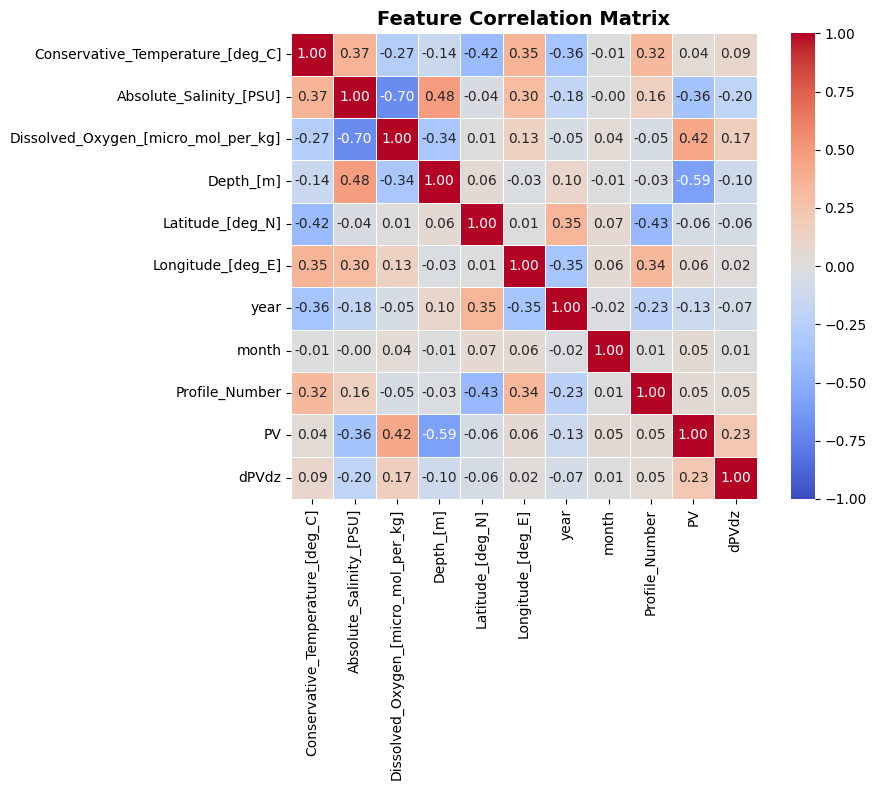

In [6]:
# Compute
corr = df_ST.corr()

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    ax=ax,
    cmap="coolwarm",
    vmin=-1, vmax=1, center=0,
    annot=True, fmt=".2f",
    linewidths=0.4, linecolor="white",
    square=True,
)
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=150, bbox_inches="tight")

In [8]:
df_sampled = method34(df_ST) # sampled the data using method34 to improve data homogeneity

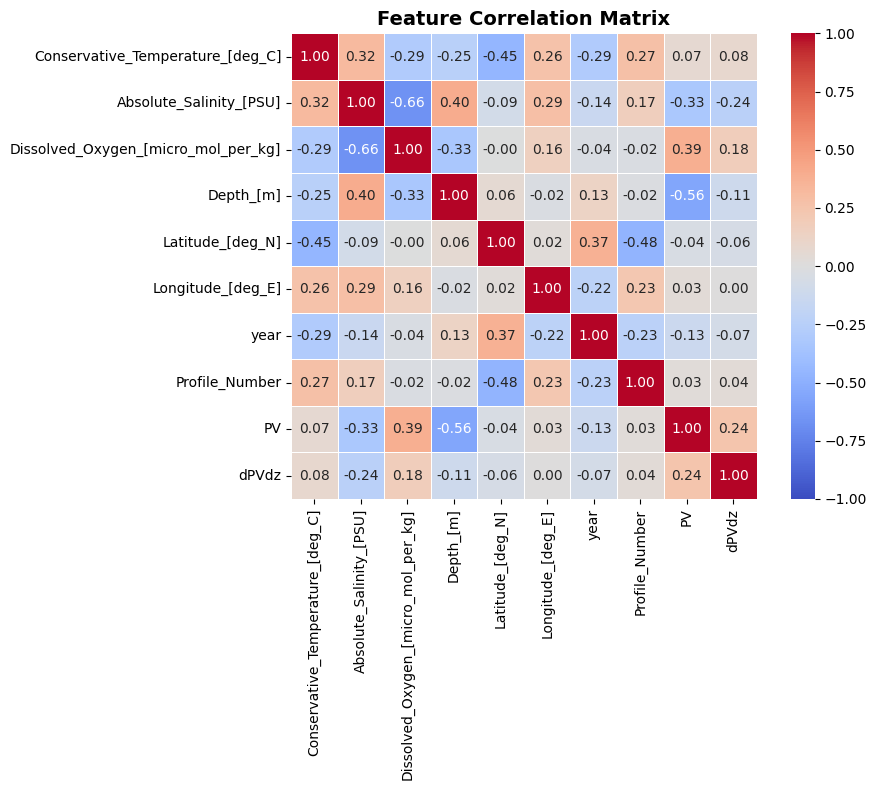

In [11]:
# Compute
s_corr = df_sampled.corr()

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    s_corr,
    ax=ax,
    cmap="coolwarm",
    vmin=-1, vmax=1, center=0,
    annot=True, fmt=".2f",
    linewidths=0.4, linecolor="white",
    square=True,
)
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_matrix_sampled.png", dpi=150, bbox_inches="tight")